<a href="https://colab.research.google.com/github/jthechen/IELE756-region-Providencia-San_Miguel-Paine/blob/main/Tarea_1_IELE756.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1 --- IELE756
**Team members**: Ja Ming Louie , José Thomas Hechenleitner
**Comunas**: Providencia (13123), San Miguel (13130), Paine (13404)
**Date**: 27 de marzo, 2026

In [38]:
#0.1
#Id comunas a trabajar:
  #Providencia (13123)
  #San Miguel (13130)
  #Paine (13404)

#Cargar data y columnas necesarias

import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

#Ruta archivos
ruta_personas = "/content/drive/MyDrive/Pre. y Análisis de datos/viv_hog_per_censo2024-2/personas_censo2024.parquet"
ruta_hogares = "/content/drive/MyDrive/Pre. y Análisis de datos/viv_hog_per_censo2024-2/hogares_censo2024.parquet"
ruta_viviendas = "/content/drive/MyDrive/Pre. y Análisis de datos/viv_hog_per_censo2024-2/viviendas_censo2024.parquet"

print("Se han cargado los archivos desde Drive")

persona = pd.read_parquet(
    ruta_personas,
    columns=["id_vivienda", "id_hogar", "id_persona", "sexo", "edad",
             "p27_nacionalidad", "p27_nacionalidad_rec", "p24_lug_resid5", "p25_lug_nacimiento",
             "p26_llegada_periodo", "escolaridad", "cine11", "sit_fuerza_trabajo",
             "cod_ciuo", "cod_caenes", "p45_medio_transporte"]
)


print("DataFrame 'persona' cargado con las columnas seleccionadas.")
display(persona.head())

vivienda = pd.read_parquet(
    ruta_viviendas,
    columns=["id_vivienda", "region", "comuna",
             "p4a_mat_paredes"]
)

print("DataFrame 'vivienda' cargado con las columnas seleccionadas.")
display(vivienda.head())

hogares = pd.read_parquet(
    ruta_hogares,
    columns=["id_vivienda", "id_hogar", "p12_tenencia_viv"]
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Se han cargado los archivos desde Drive
DataFrame 'persona' cargado con las columnas seleccionadas.


,id_vivienda,id_hogar,id_persona,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,p24_lug_resid5,p25_lug_nacimiento,p26_llegada_periodo,escolaridad,cine11,sit_fuerza_trabajo,cod_ciuo,cod_caenes,p45_medio_transporte
0,1,1,1,2,80,1,1,3,2,NaN,17,9,3.0,NaN,None,NaN
1,1,1,2,1,52,1,1,2,2,NaN,14,6,1.0,7.0,F,2.0
2,1,1,3,2,45,1,1,2,2,NaN,12,6,1.0,2.0,P,3.0
3,1,1,4,2,8,1,1,2,1,NaN,2,3,NaN,NaN,None,NaN
4,2,1,1,1,69,1,1,3,2,NaN,12,6,3.0,NaN,None,NaN


DataFrame 'vivienda' cargado con las columnas seleccionadas.


,id_vivienda,region,comuna,p4a_mat_paredes
0,1,5,5802,5.0
1,2,4,4303,2.0
2,3,11,11202,2.0
3,4,1,1101,1.0
4,5,8,8301,2.0


In [39]:
#0.2 Filtrar tabla

my_comunas = {13130, 13123, 13404}

viv = vivienda[vivienda["comuna"].isin(my_comunas)]
hog = hogares[hogares["id_vivienda"].isin(viv["id_vivienda"])]
per = persona[persona["id_vivienda"].isin(viv["id_vivienda"])]

#Reporte del número de filas del DataFrame
print(f"Número de filas en el DataFrame viv: {viv.shape[0]}")
print(f"Número de filas en el DataFrame hog: {hog.shape[0]}")
print(f"Número de filas en el DataFrame per: {per.shape[0]}")




Número de filas en el DataFrame viv: 173463
Número de filas en el DataFrame hog: 155785
Número de filas en el DataFrame per: 373631


In [40]:
df = per.merge(hog, on=["id_vivienda", "id_hogar"], how="left") \
    .merge(viv, on="id_vivienda", how="left")

# Verificar que el número de filas no cambie después de las uniones
assert len(df) == len(per), "¡Desajuste en el conteo de filas después de la unión!"

print(f"Shape del DataFrame final (df): {df.shape}")
print("Información del DataFrame final (df):")
df.info()

Shape del DataFrame final (df): (373631, 20)
Información del DataFrame final (df):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373631 entries, 0 to 373630
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id_vivienda           373631 non-null  int32  
 1   id_hogar              373631 non-null  int32  
 2   id_persona            373631 non-null  int32  
 3   sexo                  373631 non-null  int32  
 4   edad                  373631 non-null  int32  
 5   p27_nacionalidad      373631 non-null  int32  
 6   p27_nacionalidad_rec  373631 non-null  int32  
 7   p24_lug_resid5        373631 non-null  int32  
 8   p25_lug_nacimiento    373631 non-null  int32  
 9   p26_llegada_periodo   60747 non-null   float64
 10  escolaridad           373631 non-null  int32  
 11  cine11                373631 non-null  int32  
 12  sit_fuerza_trabajo    317607 non-null  float64
 13  cod_ciuo             

Parte n°1

/tmp/ipykernel_26967/2569432459.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  population_data = df_filtered.groupby(['age_group', 'sexo_label', 'nacionalidad_label']).size().unstack(fill_value=0).stack().reset_index(name='count')
/tmp/ipykernel_26967/2569432459.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  male_data = population_data[population_data['sexo_label'] == 'Hombre'].pivot_table(index='age_group', columns='nacionalidad_label', values='count_male', fill_value=0)
/tmp/ipykernel_26967/2569432459.py:35: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future versio

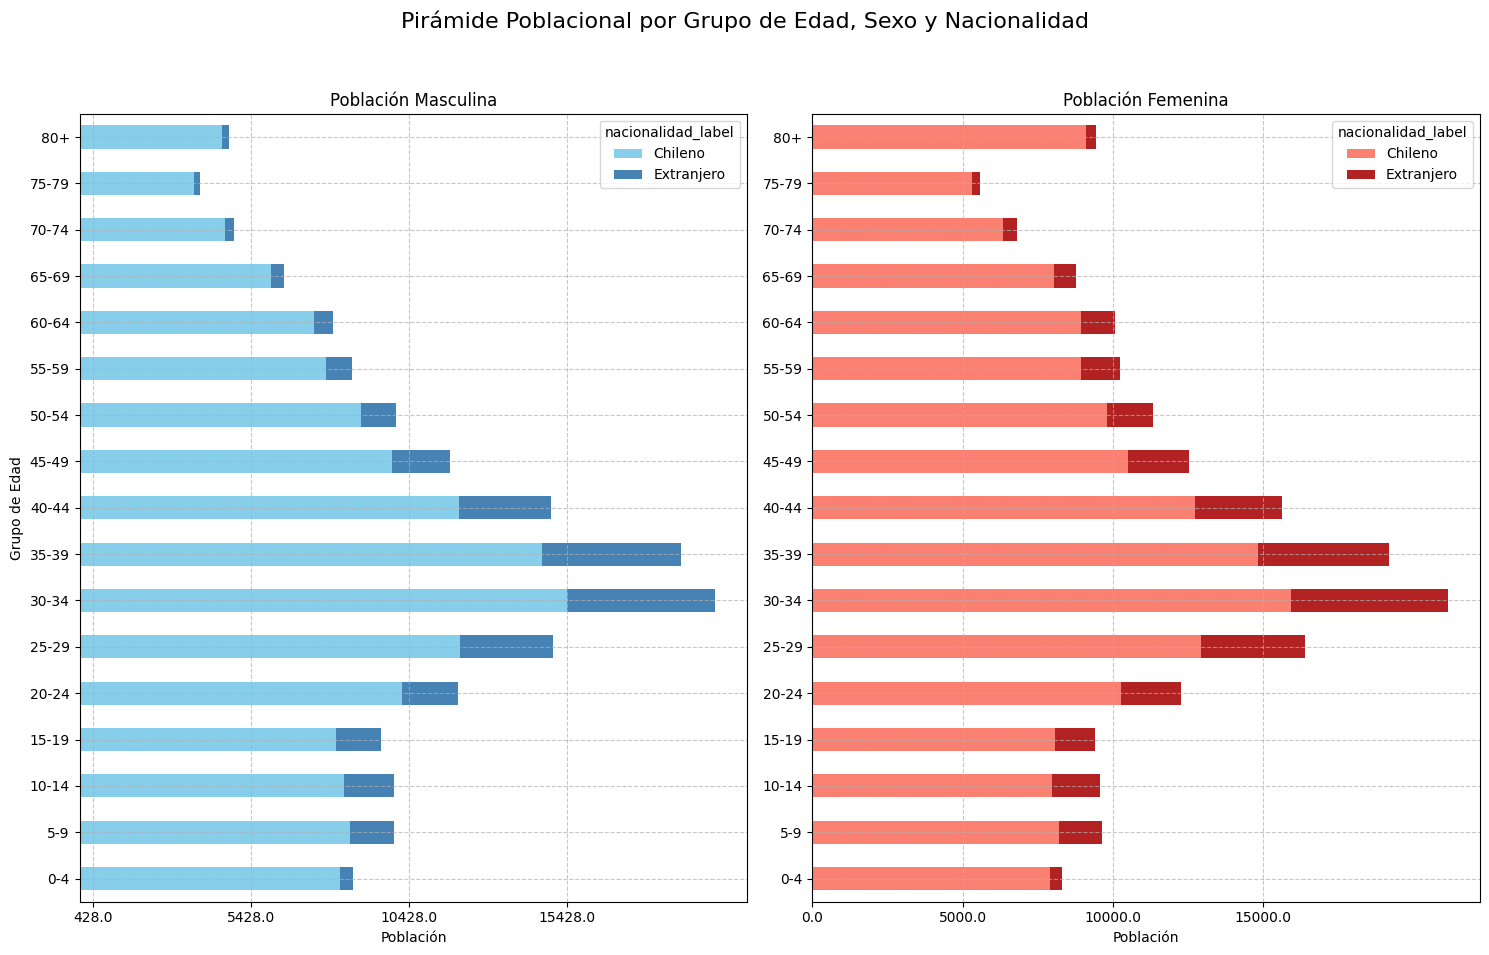

In [41]:
#Parte 1:

#Parte 1.1:

#importar librerías gráficas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filter out missing 'edad' values (-99)
df_filtered = df[df['edad'] != -99].copy()

# 2. Create age bins
bins = list(range(0, 81, 5)) + [200]
labels = [f"{i}-{i+4}" for i in range(0, 80, 5)] + ["80+"]
df_filtered["age_group"] = pd.cut(df_filtered["edad"], bins=bins, labels=labels, right=False)

# Map sexo (assuming 1=Male, 2=Female based on common census data)
df_filtered['sexo_label'] = df_filtered['sexo'].map({1: 'Hombre', 2: 'Mujer'})

# Map p27_nacionalidad_rec (assuming 1=Chilena, others=Extranjera)
df_filtered['nacionalidad_label'] = df_filtered['p27_nacionalidad_rec'].apply(lambda x: 'Chileno' if x == 1 else 'Extranjero')


# Preparación de piramide poblacional
# Agrupar por age_group, sexo_label, and nacionalidad_label
population_data = df_filtered.groupby(['age_group', 'sexo_label', 'nacionalidad_label']).size().unstack(fill_value=0).stack().reset_index(name='count')

# Separate male and female counts and make male counts negative for plotting
population_data['count_male'] = population_data.apply(lambda row: -row['count'] if row['sexo_label'] == 'Hombre' else 0, axis=1)
population_data['count_female'] = population_data.apply(lambda row: row['count'] if row['sexo_label'] == 'Mujer' else 0, axis=1)

# Pivot the table for plotting
male_data = population_data[population_data['sexo_label'] == 'Hombre'].pivot_table(index='age_group', columns='nacionalidad_label', values='count_male', fill_value=0)
female_data = population_data[population_data['sexo_label'] == 'Mujer'].pivot_table(index='age_group', columns='nacionalidad_label', values='count_female', fill_value=0)

# Ensure all age groups are present and in order
all_age_groups = pd.Categorical(labels, categories=labels, ordered=True)
male_data = male_data.reindex(all_age_groups, fill_value=0)
female_data = female_data.reindex(all_age_groups, fill_value=0)

#Ajustes gráfico
# Plotting
fig, axes = plt.subplots(ncols=2, figsize=(15, 10), sharey=True)

# Plot Males
male_data.plot(kind='barh', stacked=True, ax=axes[0], color={'Chileno': 'skyblue', 'Extranjero': 'steelblue'})
axes[0].set_title('Población Masculina')
axes[0].set_ylabel('Grupo de Edad')
axes[0].set_xlabel('Población')
axes[0].invert_xaxis() # Invert x-axis for left side of pyramid
axes[0].set_xticks(np.arange(male_data.min().min(), 0, 5000))
axes[0].set_xticklabels([abs(x) for x in np.arange(male_data.min().min(), 0, 5000)])
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Females
female_data.plot(kind='barh', stacked=True, ax=axes[1], color={'Chileno': 'salmon', 'Extranjero': 'firebrick'})
axes[1].set_title('Población Femenina')
axes[1].set_xlabel('Población')
axes[1].set_xticks(np.arange(0, female_data.max().max(), 5000))
axes[1].set_xticklabels([x for x in np.arange(0, female_data.max().max(), 5000)])
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].yaxis.set_tick_params(labelleft=True) # Ensure y-labels are visible on both sides

plt.suptitle('Pirámide Poblacional por Grupo de Edad, Sexo y Nacionalidad', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [42]:
#Parte 1.2: Razón de dependencia por edad
# Filter out missing 'edad' values, ensuring 'df_filtered' is up-to-date
df_dependency = df[df['edad'] != -99].copy()

# Define age groups for dependency ratio
def get_age_group(edad):
    if 0 <= edad <= 14:
        return '0-14'
    elif 15 <= edad <= 64:
        return '15-64'
    elif edad >= 65:
        return '65+'
    return None # For any unexpected age values

df_dependency['age_group_dependency'] = df_dependency['edad'].apply(get_age_group)

# Group by comuna and age_group_dependency to get counts
population_by_comuna_age = df_dependency.groupby(['comuna', 'age_group_dependency']).size().unstack(fill_value=0)

# Calculate dependency ratio
# Dependency ratio = (Population aged 0-14 + Population aged 65+) / Population aged 15-64

# Ensure all necessary columns exist before calculation
for col in ['0-14', '15-64', '65+']:
    if col not in population_by_comuna_age.columns:
        population_by_comuna_age[col] = 0

population_by_comuna_age['dependency_ratio'] = \
    (population_by_comuna_age['0-14'] + population_by_comuna_age['65+']) / population_by_comuna_age['15-64']

# Select and display relevant columns
dependency_ratio_table = population_by_comuna_age[['0-14', '15-64', '65+', 'dependency_ratio']]
print("Tabla de Razón de Dependencia por Comuna:")
display(dependency_ratio_table)


Tabla de Razón de Dependencia por Comuna:


age_group_dependency,0-14,15-64,65+,dependency_ratio
comuna,,,,
13123,17123,103746,23105,0.387755
13130,23562,109944,17323,0.371871
13404,15339,53411,10078,0.475876


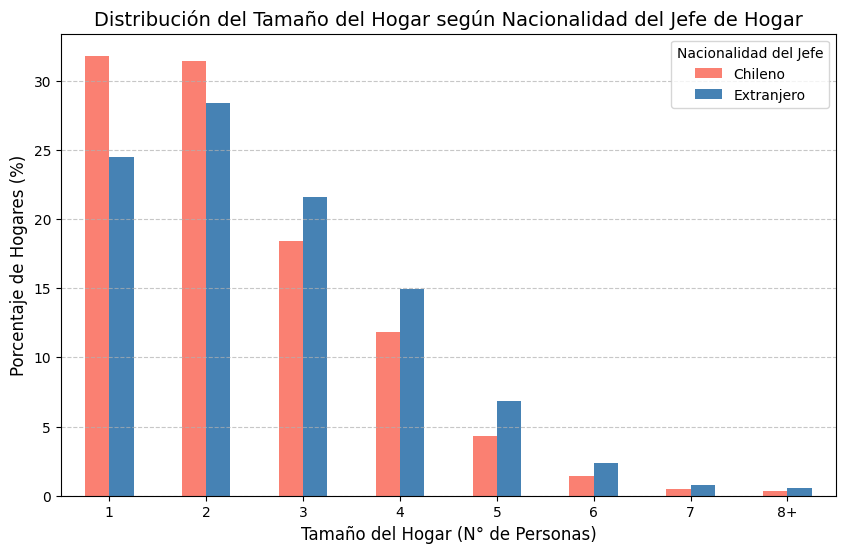

In [43]:
#Parte 1.3: Distribución del tamaño del hogar

# Identificamos la nacionalidad del "Jefe de Hogar" (asumiendo id_persona == 1)
jefes_hogar = df[df['id_persona'] == 1][['id_vivienda', 'id_hogar', 'p27_nacionalidad_rec']].copy()
jefes_hogar['Nacionalidad_Jefe'] = np.where(jefes_hogar['p27_nacionalidad_rec'] == 1, 'Chileno', 'Extranjero')

# Calculamos el tamaño de cada hogar (contando cuántas filas/personas hay por hogar)
tamano_hogar = df.groupby(['id_vivienda', 'id_hogar']).size().reset_index(name='Tamano')

# Agrupamos los tamaños mayores o iguales a 8 en la categoría "8+"
tamano_hogar['Tamano_cat'] = tamano_hogar['Tamano'].apply(lambda x: str(x) if x < 8 else '8+')

# Unimos el tamaño del hogar con la nacionalidad de su jefe
hogares = tamano_hogar.merge(jefes_hogar[['id_vivienda', 'id_hogar', 'Nacionalidad_Jefe']],
                             on=['id_vivienda', 'id_hogar'], how='inner')

# Calculamos la proporción (%) para poder comparar justamente ambas poblaciones
distribucion = hogares.groupby(['Nacionalidad_Jefe', 'Tamano_cat']).size().unstack(fill_value=0)
distribucion_pct = distribucion.div(distribucion.sum(axis=1), axis=0) * 100

# Ordenamos las columnas lógicamente
cols_order = [str(i) for i in range(1, 8)] + ['8+']
distribucion_pct = distribucion_pct.reindex(columns=cols_order)

# Graficamos
ax = distribucion_pct.T.plot(kind='bar', figsize=(10, 6), color=['salmon', 'steelblue'])
plt.title('Distribución del Tamaño del Hogar según Nacionalidad del Jefe de Hogar', fontsize=14)
plt.xlabel('Tamaño del Hogar (N° de Personas)', fontsize=12)
plt.ylabel('Porcentaje de Hogares (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Nacionalidad del Jefe')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_26967/3088319527.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_educ, x='Nacionalidad', y='escolaridad', ax=axes[0], palette='Set2')


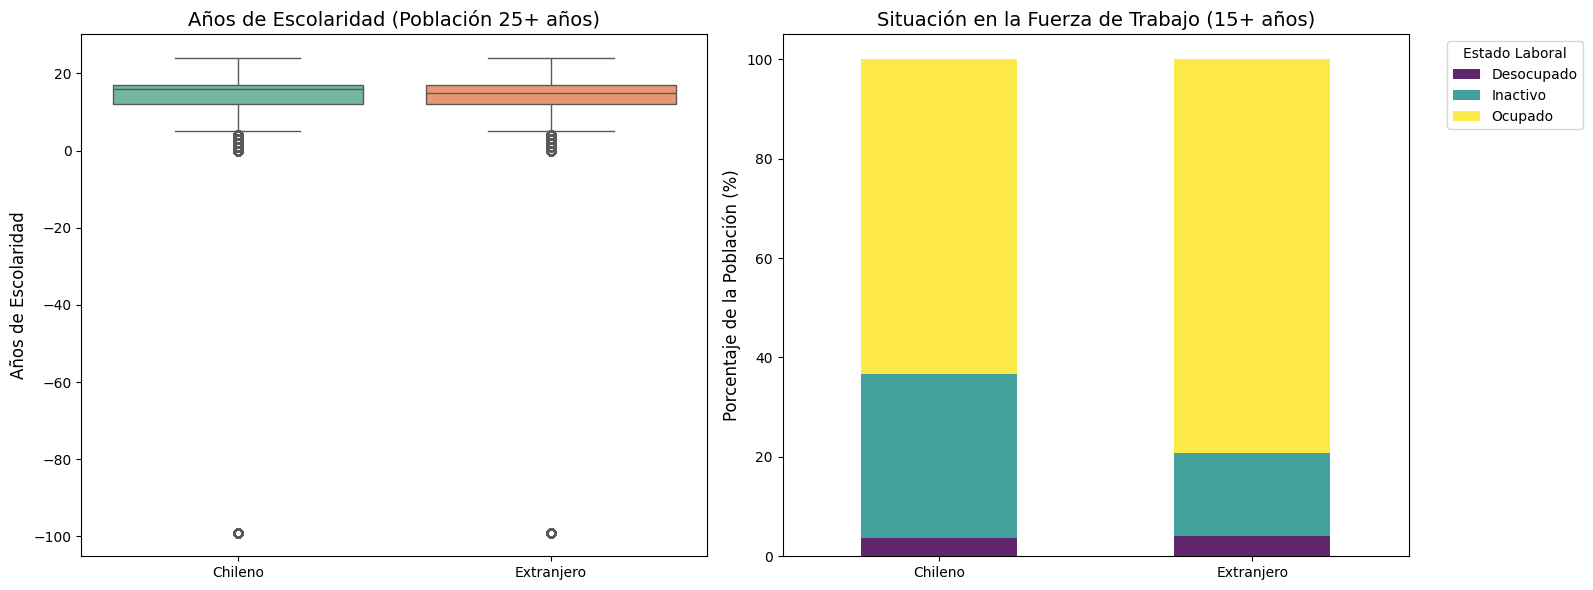

In [44]:
#Parte 1.4: Educación y Empleo
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos una columna más limpia para la nacionalidad (1 = Chileno, el resto Extranjero)
df['Nacionalidad'] = np.where(df['p27_nacionalidad_rec'] == 1, 'Chileno', 'Extranjero')

# Diccionario para traducir los códigos de empleo del Censo
dicc_empleo = {
    1: 'Ocupado',
    2: 'Desocupado',
    3: 'Inactivo'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO A: EDUCACIÓN (Mayores de 25 años)
df_educ = df[df['edad'] >= 25].copy()
# Filtramos posibles valores anómalos de escolaridad
df_educ = df_educ[df_educ['escolaridad'] < 30]

sns.boxplot(data=df_educ, x='Nacionalidad', y='escolaridad', ax=axes[0], palette='Set2')
axes[0].set_title('Años de Escolaridad (Población 25+ años)', fontsize=14)
axes[0].set_ylabel('Años de Escolaridad', fontsize=12)
axes[0].set_xlabel('')

# GRÁFICO B: EMPLEO (Mayores de 15 años)
df_empleo = df[df['edad'] >= 15].copy()
df_empleo['Estado_Laboral'] = df_empleo['sit_fuerza_trabajo'].map(dicc_empleo)

# Calculamos el % de cada estado laboral por nacionalidad
empleo_pct = (df_empleo.groupby('Nacionalidad')['Estado_Laboral']
              .value_counts(normalize=True)
              .unstack() * 100)

empleo_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis', alpha=0.85)
axes[1].set_title('Situación en la Fuerza de Trabajo (15+ años)', fontsize=14)
axes[1].set_ylabel('Porcentaje de la Población (%)', fontsize=12)
axes[1].set_xlabel('')
axes[1].legend(title='Estado Laboral', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Parte n°2

TABLA: PORCENTAJE DE POBLACIÓN EXTRANJERA POR COMUNA
-------------------------------------------------------
Nacionalidad        % Extranjeros
Comuna_Etiqueta                  
13123 - Providencia        9.14 %
13130 - San Miguel        25.65 %
13404 - Paine              7.09 %
-------------------------------------------------------


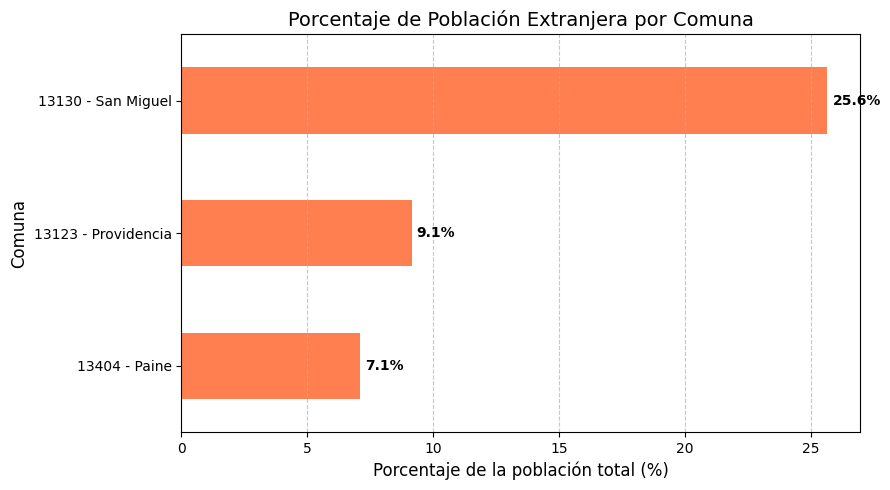

In [45]:
#Parte 2.1: Porcentaje de Extranjeros por Comuna (Nombres)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# DICCIONARIO CORREGIDO: De número a "Número - Nombre"
codigos = {
    13123: "13123 - Providencia",
    13130: "13130 - San Miguel",
    13404: "13404 - Paine"
}

# Reemplazamos los números por nuestra etiqueta completa usando map()
df['Comuna_Etiqueta'] = df['comuna'].map(codigos)

# Creamos la columna 'Nacionalidad'
df['Nacionalidad'] = np.where(df['p27_nacionalidad_rec'] == 1, 'Chileno', 'Extranjero')

# Calculamos el porcentaje
resumen_migracion = pd.crosstab(df['Comuna_Etiqueta'], df['Nacionalidad'], normalize='index') * 100

# Aislamos solo la columna de extranjeros para la tabla
tabla_extranjeros = resumen_migracion[['Extranjero']].rename(columns={'Extranjero': '% Extranjeros'})

print("TABLA: PORCENTAJE DE POBLACIÓN EXTRANJERA POR COMUNA")
print("-" * 55)
print(tabla_extranjeros.round(2).astype(str) + ' %')
print("-" * 55)

# Creamos el gráfico de barras horizontales
ax = tabla_extranjeros.sort_values(by='% Extranjeros', ascending=True).plot(
    kind='barh',
    color='coral',
    figsize=(9, 5),
    legend=False
)

plt.title('Porcentaje de Población Extranjera por Comuna', fontsize=14)
plt.xlabel('Porcentaje de la población total (%)', fontsize=12)
plt.ylabel('Comuna', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

#Le ponemos el número exacto al lado a cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width() + 0.2, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

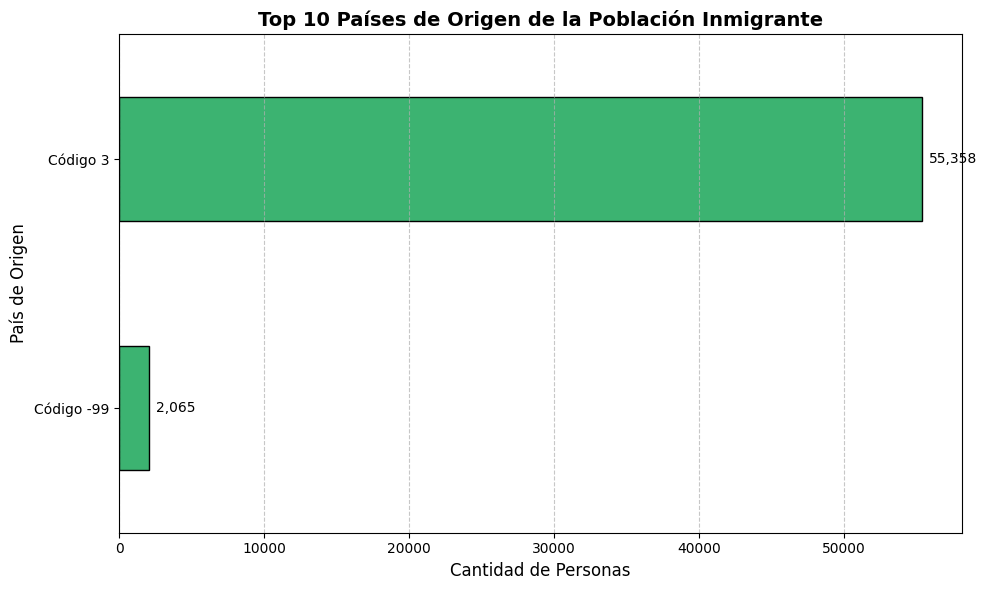

solo hay 2 nacionalidades inmigrantes en esta comuna


In [46]:
#Parte 2.2: Top 10 Nacionalidades
import matplotlib.pyplot as plt
import pandas as pd

# Filtramos la tabla para quedarnos ÚNICAMENTE con la población extranjera
df_extranjeros = df[df['Nacionalidad'] == 'Extranjero'].copy()

# Contamos por país y usamos .head(10) para sacar el TOP 10 exacto
top_10_paises = df_extranjeros['p27_nacionalidad'].value_counts(dropna=True).head(10)

# Diccionario traductor (para decodificar los números a nombres)
paises_comunes = {
    862: 'Venezuela', 170: 'Colombia', 604: 'Perú', 332: 'Haití',
    68: 'Bolivia', 32: 'Argentina', 218: 'Ecuador', 600: 'Paraguay',
    858: 'Uruguay', 76: 'Brasil', 724: 'España', 840: 'Estados Unidos',
    156: 'China', 192: 'Cuba', 214: 'República Dominicana'
}

# Traducimos los códigos a nombres reales
if pd.api.types.is_numeric_dtype(top_10_paises.index):
    top_10_paises.index = top_10_paises.index.map(lambda x: paises_comunes.get(x, f"Código {x}"))

# Creamos el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
# sort_values() ordena de menor a mayor para que el país #1 quede en la cima del gráfico
ax = top_10_paises.sort_values().plot(kind='barh', color='mediumseagreen', edgecolor='black')

plt.title('Top 10 Países de Origen de la Población Inmigrante', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Personas', fontsize=12)
plt.ylabel('País de Origen', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Le ponemos la cantidad exacta al lado de cada barra
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()
print("solo hay 2 nacionalidades inmigrantes en esta comuna")

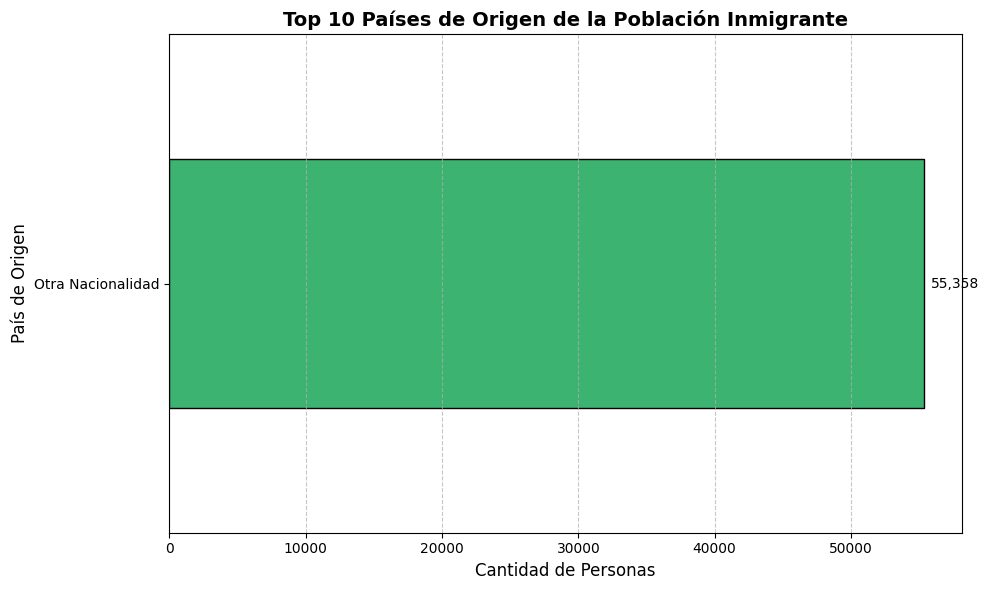

In [47]:
#Parte 2.2: Top 10 Nacionalidades (con los nombres de las nacionalidades)
import matplotlib.pyplot as plt
import pandas as pd

# Filtramos Extranjeros Y eliminamos los datos perdidos (-99)
df_extranjeros = df[(df['Nacionalidad'] == 'Extranjero') & (df['p27_nacionalidad'] != -99)].copy()

# Contamos por país y sacamos el Top 10
top_10_paises = df_extranjeros['p27_nacionalidad'].value_counts(dropna=True).head(10)

# Diccionario traductor (solo con los nombres)
paises_comunes = {
    862: 'Venezuela', 170: 'Colombia', 604: 'Perú', 332: 'Haití',
    68: 'Bolivia', 32: 'Argentina', 218: 'Ecuador', 600: 'Paraguay',
    858: 'Uruguay', 76: 'Brasil', 724: 'España', 840: 'Estados Unidos',
    156: 'China', 192: 'Cuba', 214: 'República Dominicana',
    3: 'Otra Nacionalidad' # <-- Cambia esto si descubres qué es el 3
}

# Traducimos los códigos a SOLAMENTE el nombre del país
if pd.api.types.is_numeric_dtype(top_10_paises.index):
    top_10_paises.index = top_10_paises.index.map(lambda x: paises_comunes.get(x, f"País Desconocido ({x})"))

# Creamos el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
ax = top_10_paises.sort_values().plot(kind='barh', color='mediumseagreen', edgecolor='black')

plt.title('Top 10 Países de Origen de la Población Inmigrante', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Personas', fontsize=12)
plt.ylabel('País de Origen', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Le ponemos la cantidad exacta al lado de cada barra
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}",
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

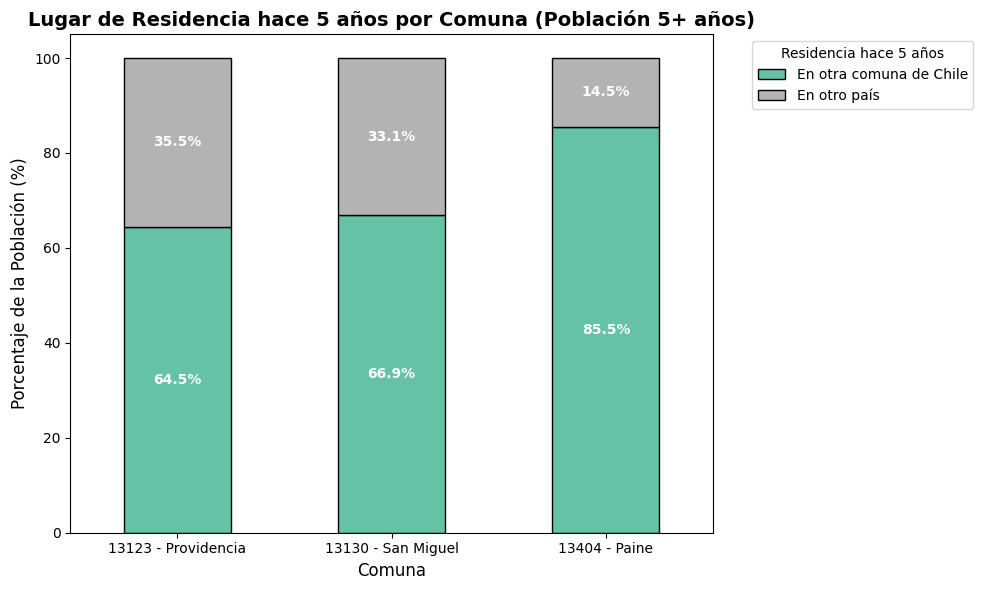

In [48]:
#Parte 2.3: Residencia hace 5 años
import matplotlib.pyplot as plt
import pandas as pd

# Filtro: Mayores o iguales a 5 años Y que hayan respondido la pregunta (distinto a -99)
df_5_anos = df[(df['edad'] >= 5) & (df['p24_lug_resid5'] != -99)].copy()

# Diccionario para la variable de residencia
dicc_residencia = {
    1: 'En esta misma comuna',
    2: 'En otra comuna de Chile',
    3: 'En otro país'
    # Si hay un código 4 (ej. "No sabe"), lo ignorará o puedes agregarlo aquí
}

# Traducimos los códigos a texto
df_5_anos['Residencia_Hace_5_Años'] = df_5_anos['p24_lug_resid5'].map(dicc_residencia)

# Calculamos la proporción (%) de cada respuesta por comuna
# Usamos la columna 'Comuna_Etiqueta' que creamos en el 2.1 para que salgan los nombres
residencia_pct = pd.crosstab(
    df_5_anos['Comuna_Etiqueta'],
    df_5_anos['Residencia_Hace_5_Años'],
    normalize='index'
) * 100

# Ordenamos las columnas para que el gráfico tenga lógica visual
orden_cols = ['En esta misma comuna', 'En otra comuna de Chile', 'En otro país']
residencia_pct = residencia_pct.reindex(columns=[c for c in orden_cols if c in residencia_pct.columns])

# Creamos el gráfico de barras apiladas (Stacked Bar Chart)
ax = residencia_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='Set2',
    edgecolor='black'
)

plt.title('Lugar de Residencia hace 5 años por Comuna (Población 5+ años)', fontsize=14, fontweight='bold')
plt.xlabel('Comuna', fontsize=12)
plt.ylabel('Porcentaje de la Población (%)', fontsize=12)
plt.xticks(rotation=0)
# Movemos la leyenda afuera del gráfico para que no tape las barras
plt.legend(title='Residencia hace 5 años', bbox_to_anchor=(1.05, 1), loc='upper left')

# Le ponemos el porcentaje escrito adentro de cada bloque de color
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 2: # Solo ponemos texto si la barra es mayor al 2% para que no se amontonen los números
        ax.text(x + width/2,
                y + height/2,
                f'{height:.1f}%',
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

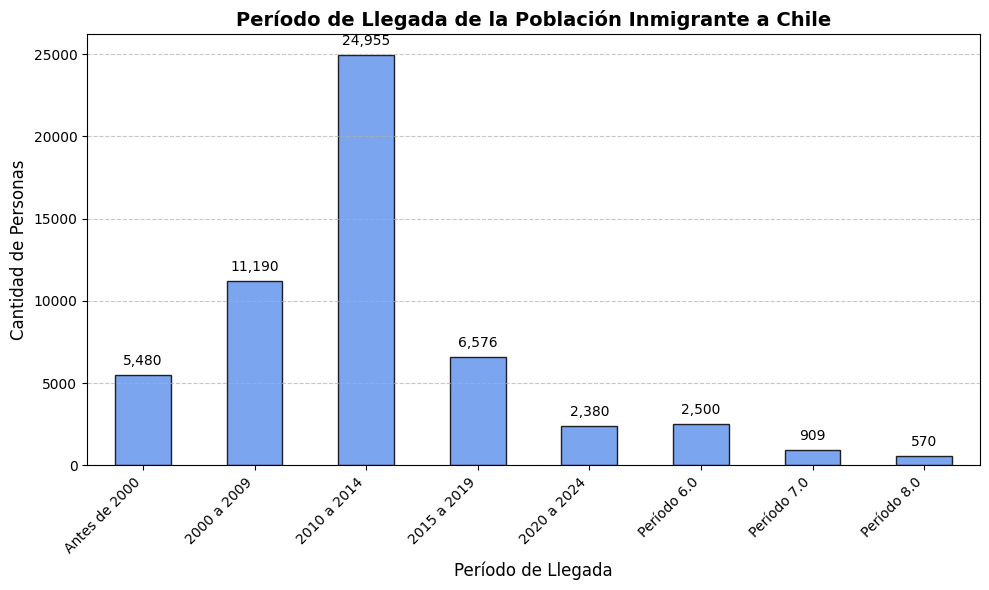

In [49]:
#Parte 2.4: Período de Llegada
import matplotlib.pyplot as plt
import pandas as pd

# Filtramos: Solo extranjeros y eliminamos los datos perdidos (-99)
df_llegada = df[(df['Nacionalidad'] == 'Extranjero') & (df['p26_llegada_periodo'] != -99)].copy()

# Contamos cuántas personas llegaron en cada período y ordenamos cronológicamente (.sort_index())
llegada_counts = df_llegada['p26_llegada_periodo'].value_counts().sort_index()

# DIiccionario: Revisado con el Excel
dicc_periodos = {
    1: 'Antes de 2000',
    2: '2000 a 2009',
    3: '2010 a 2014',
    4: '2015 a 2019',
    5: '2020 a 2024'
}

# Traducimos los códigos a texto si es que vienen como números
if pd.api.types.is_numeric_dtype(llegada_counts.index):
    llegada_counts.index = llegada_counts.index.map(lambda x: dicc_periodos.get(x, f'Período {x}'))

# Creamos un gráfico de barras verticales
plt.figure(figsize=(10, 6))
# Usamos un color distinto
ax = llegada_counts.plot(kind='bar', color='cornflowerblue', edgecolor='black', alpha=0.85)

plt.title('Período de Llegada de la Población Inmigrante a Chile', fontsize=14, fontweight='bold')
plt.xlabel('Período de Llegada', fontsize=12)
plt.ylabel('Cantidad de Personas', fontsize=12)
# Rotamos un poco los textos de abajo para que no se choquen
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Le ponemos el número exacto arriba a cada barra
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

Parte n°3

In [50]:
import os
import shutil
import geopandas as gpd

# Definimos las rutas
carpeta_origen = "/content/drive/MyDrive/Pre. y Análisis de datos"
carpeta_destino = "/content/mapa_seguro"

# Creamos la carpeta temporal limpia
os.makedirs(carpeta_destino, exist_ok=True)
print(" Copiando archivos del mapa a una zona segura...")

# Copiamos todos los archivos que se llamen "comunas" (el .shp, .dbf, .shx, etc.)
archivos_copiados = 0
for archivo in os.listdir(carpeta_origen):
    if archivo.startswith("comunas."): # Busca comunas.shp, comunas.dbf, etc.
        origen = os.path.join(carpeta_origen, archivo)
        destino = os.path.join(carpeta_destino, archivo)
        shutil.copy2(origen, destino)
        archivos_copiados += 1

print(f"Se encontraron y copiaron {archivos_copiados} archivos del shapefile.")

# Intentamos leer el mapa desde la nueva ubicación segura
ruta_segura = f"{carpeta_destino}/comunas.shp"

try:
    mapa_comunas = gpd.read_file(ruta_segura)
    print("¡Bien! El mapa base se ha cargado a la perfección.")
    print(f"Total de comunas en el mapa de Chile: {len(mapa_comunas)}")
except Exception as e:
    print(f"\n Sigue el error. Detalle: {e}")
    print("\n DIAGNÓSTICO: Si copió los archivos pero sigue fallando")

 Copiando archivos del mapa a una zona segura...
Se encontraron y copiaron 8 archivos del shapefile.
¡Bien! El mapa base se ha cargado a la perfección.
Total de comunas en el mapa de Chile: 346


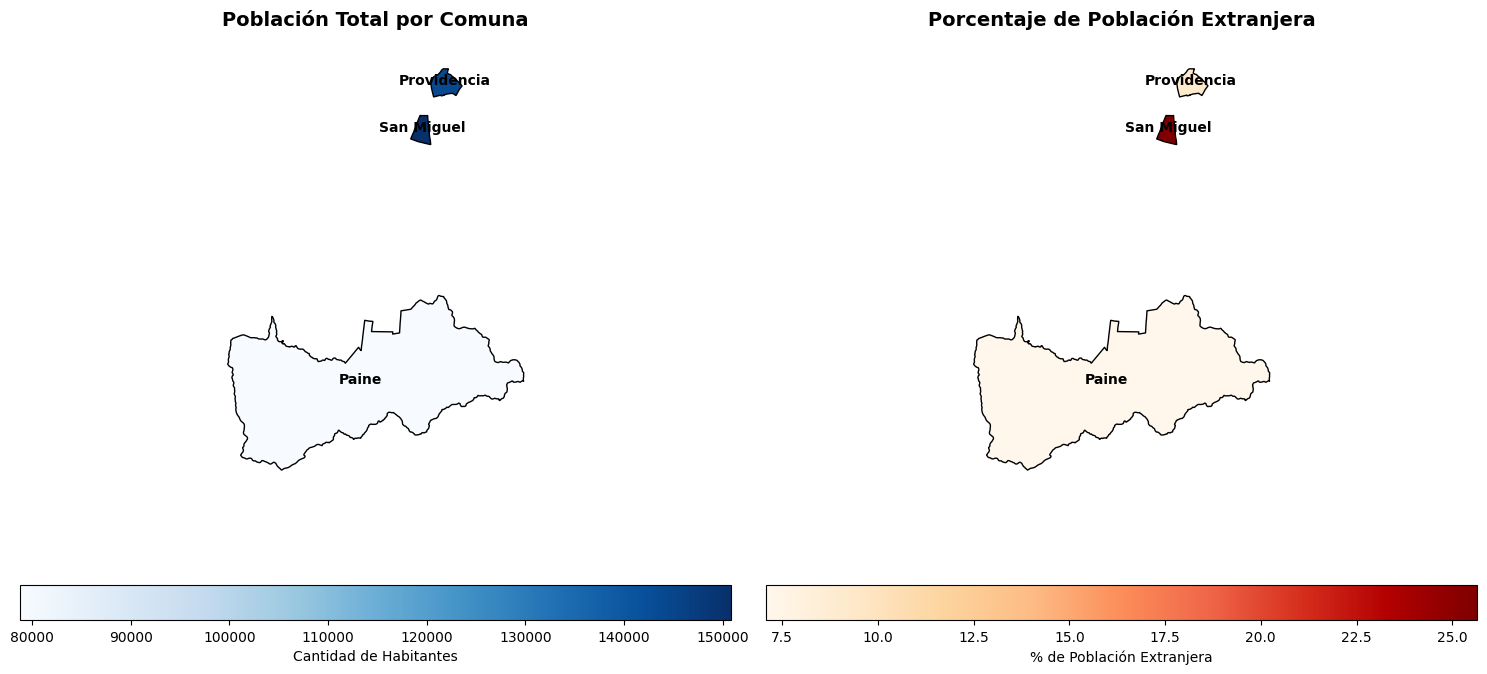

In [51]:
# Parte 3.1 y 3.2: Visualización Espacial
import matplotlib.pyplot as plt
import numpy as np

# Ajustar nombres de columnas a mayúsculas
mapa_comunas.columns = mapa_comunas.columns.str.upper()

# Se ve en Python cuál es la columna de los dibujos
mapa_comunas = mapa_comunas.set_geometry('GEOMETRY')

# Sabemos que el código numérico está en 'COD_COMUNA'
col_codigo = 'COD_COMUNA'
mapa_comunas[col_codigo] = mapa_comunas[col_codigo].astype(int)
col_nombre = 'COMUNA'

# Preparamos los datos del CENSO
df['Nacionalidad'] = np.where(df['p27_nacionalidad_rec'] == 1, 'Chileno', 'Extranjero')

# Agrupamos por comuna
datos_mapa = df.groupby('comuna').agg(
    Poblacion_Total=('id_persona', 'count'),
    Total_Extranjeros=('Nacionalidad', lambda x: (x == 'Extranjero').sum())
).reset_index()

# Calculamos el porcentaje
datos_mapa['Pct_Extranjeros'] = (datos_mapa['Total_Extranjeros'] / datos_mapa['Poblacion_Total']) * 100

# El cruce (MERGE)
mapa_final = mapa_comunas.merge(datos_mapa, left_on=col_codigo, right_on='comuna', how='inner')

# Dibujar mapa
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Mapa A: Población Total
mapa_final.plot(
    column='Poblacion_Total', ax=axes[0], cmap='Blues',
    legend=True, edgecolor='black', linewidth=1,
    legend_kwds={'label': "Cantidad de Habitantes", 'orientation': "horizontal"}
)
axes[0].set_title('Población Total por Comuna', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Mapa B: Porcentaje de Extranjeros
mapa_final.plot(
    column='Pct_Extranjeros', ax=axes[1], cmap='OrRd',
    legend=True, edgecolor='black', linewidth=1,
    legend_kwds={'label': "% de Población Extranjera", 'orientation': "horizontal"}
)
axes[1].set_title('Porcentaje de Población Extranjera', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Etiquetas con el nombre de la comuna
for idx, row in mapa_final.iterrows():
    centro = row.GEOMETRY.centroid
    axes[0].annotate(text=row[col_nombre], xy=(centro.x, centro.y), ha='center', fontsize=10, weight='bold')
    axes[1].annotate(text=row[col_nombre], xy=(centro.x, centro.y), ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

Parte n°4

In [52]:
# Parte 4: Tabla de Resumen por Comuna
import pandas as pd
import numpy as np

# Diccionario de nombres
nombres_comunas = {
    13123: "Providencia",
    13130: "San Miguel",
    13404: "Paine"
}

def build_summary(x):
    """
    Función que calcula los indicadores para cada grupo
    """
    # El valor de la comuna ahora lo tomamos de x.name
    cod_comuna = x.name

    # Filtros base
    chilenos = x[x['Nacionalidad'] == 'Chileno']
    extranjeros = x[x['Nacionalidad'] == 'Extranjero']

    # Poblaciones
    pop_total = len(x)
    pop_chilean = len(chilenos)
    pop_foreign = len(extranjeros)

    # Escolaridad (Solo 25+ años y excluyendo -99)
    # Usamos .get() o filtramos con cuidado para evitar errores si un grupo está vacío
    esc_chi = chilenos[(chilenos['edad'] >= 25) & (chilenos['escolaridad'] != -99)]['escolaridad'].mean() if pop_chilean > 0 else np.nan
    esc_for = extranjeros[(extranjeros['edad'] >= 25) & (extranjeros['escolaridad'] != -99)]['escolaridad'].mean() if pop_foreign > 0 else np.nan

    # Empleo (Tasa de ocupación: Ocupados / Población 15-64 años)
    pet_chi = chilenos[(chilenos['edad'] >= 15) & (chilenos['edad'] <= 64)]
    pet_for = extranjeros[(extranjeros['edad'] >= 15) & (extranjeros['edad'] <= 64)]

    emp_chi = (pet_chi['sit_fuerza_trabajo'] == 1).mean() * 100 if len(pet_chi) > 0 else 0
    emp_for = (pet_for['sit_fuerza_trabajo'] == 1).mean() * 100 if len(pet_for) > 0 else 0

    # Razón de Dependencia: ((<15) + (>64)) / (15 a 64) * 100
    pob_dependiente = len(x[(x['edad'] < 15) | (x['edad'] > 64)])
    pob_productiva = len(x[(x['edad'] >= 15) & (x['edad'] <= 64)])
    dep_ratio = (pob_dependiente / pob_productiva) * 100 if pob_productiva > 0 else 0

    return pd.Series({
        'nombre_comuna': nombres_comunas.get(cod_comuna, f"Código {cod_comuna}"),
        'pop_total': pop_total,
        'pop_chilean': pop_chilean,
        'pop_foreign': pop_foreign,
        'pct_foreign': (pop_foreign / pop_total) * 100 if pop_total > 0 else 0,
        'median_age_chilean': chilenos['edad'].median() if pop_chilean > 0 else np.nan,
        'median_age_foreign': extranjeros['edad'].median() if pop_foreign > 0 else np.nan,
        'mean_schooling_chilean': esc_chi,
        'mean_schooling_foreign': esc_for,
        'emp_rate_chilean': emp_chi,
        'emp_rate_foreign': emp_for,
        'dependency_ratio': dep_ratio
    })

# Aplicamos la función
# Usamos group_keys=False para evitar problemas de índices duplicados
summary = df.groupby("comuna", group_keys=False).apply(build_summary).reset_index()

# Renombramos la columna de índice
summary = summary.rename(columns={'comuna': 'codigo_comuna'})

#  Guardar como CSV
summary.to_csv("tarea1_comuna_summary.csv", index=False)

# Mostrar la tabla
print(" Tabla de resumen generada con éxito:")
from IPython.display import display
display(summary.round(2))

 Tabla de resumen generada con éxito:


/tmp/ipykernel_26967/3171492971.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby("comuna", group_keys=False).apply(build_summary).reset_index()


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13123,Providencia,143974,130820,13154,9.14,38.0,38.0,16.49,16.22,76.95,81.43,38.78
1,13130,San Miguel,150829,112146,38683,25.65,36.0,33.0,14.33,14.59,73.31,80.75,37.19
2,13404,Paine,78828,73242,5586,7.09,36.0,31.0,11.12,11.65,60.83,66.87,47.59


In [53]:
print("Fin Tarea n°1")

Fin Tarea n°1
